Đang tải dữ liệu...

--- Đánh giá chi tiết: CTGAN ---
Column               | KS Stat (Low=Good)   | Mean Diff %     | Std Diff %     
--------------------------------------------------------------------------------
Soil_Moisture_mm     | 0.0352               | 0.16%          | 0.65%
NDVI_Season_Max      | 0.0362               | 0.12%          | 6.25%
Area                 | 0.0169               | 5.68%          | 6.91%
Rainfall             | 0.0092               | 0.59%          | 0.63%
Avg Temp             | 0.0137               | 0.01%          | 0.03%
Production           | 0.0145               | 6.64%          | 9.22%
pH                   | 0.0738               | 0.02%          | 10.93%
Yield                | 0.0250               | 4.22%          | 15.38%
Nitrogen             | 0.0733               | 0.10%          | 8.85%

>> Sai lệch Tương quan trung bình (CTGAN): 0.0089

--- Đánh giá chi tiết: SMOTE ---
Column               | KS Stat (Low=Good)   | Mean Diff %     | Std Diff %   

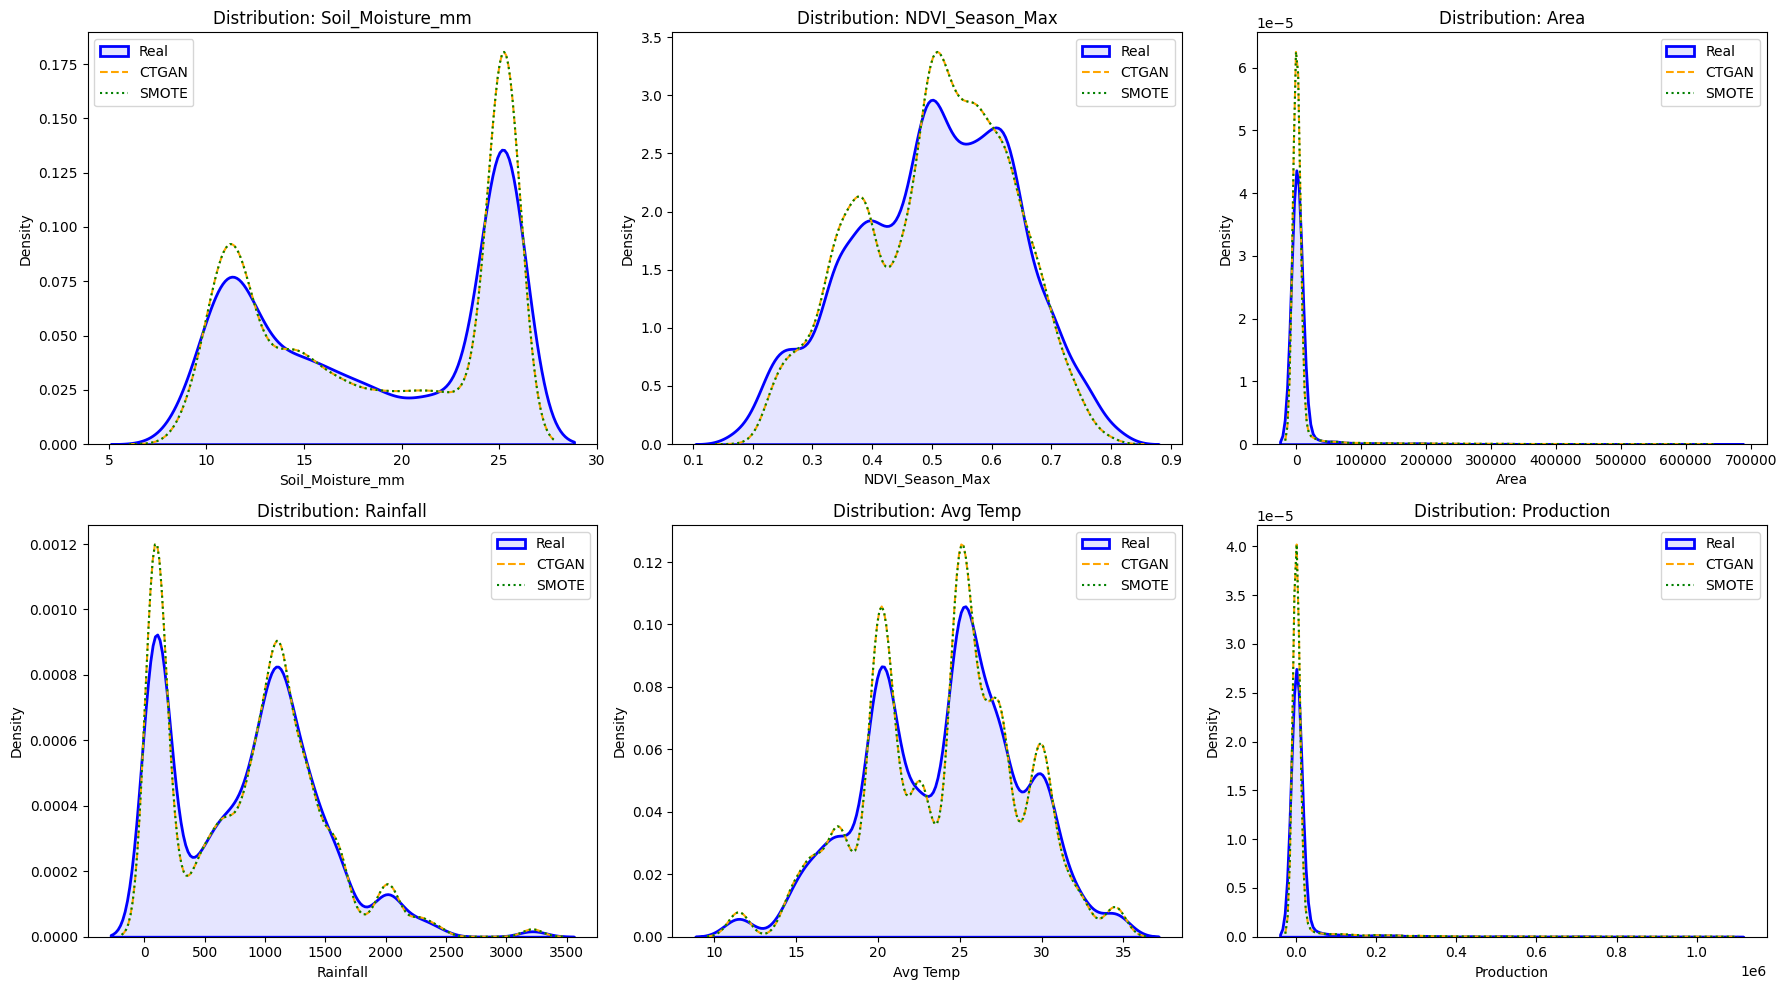

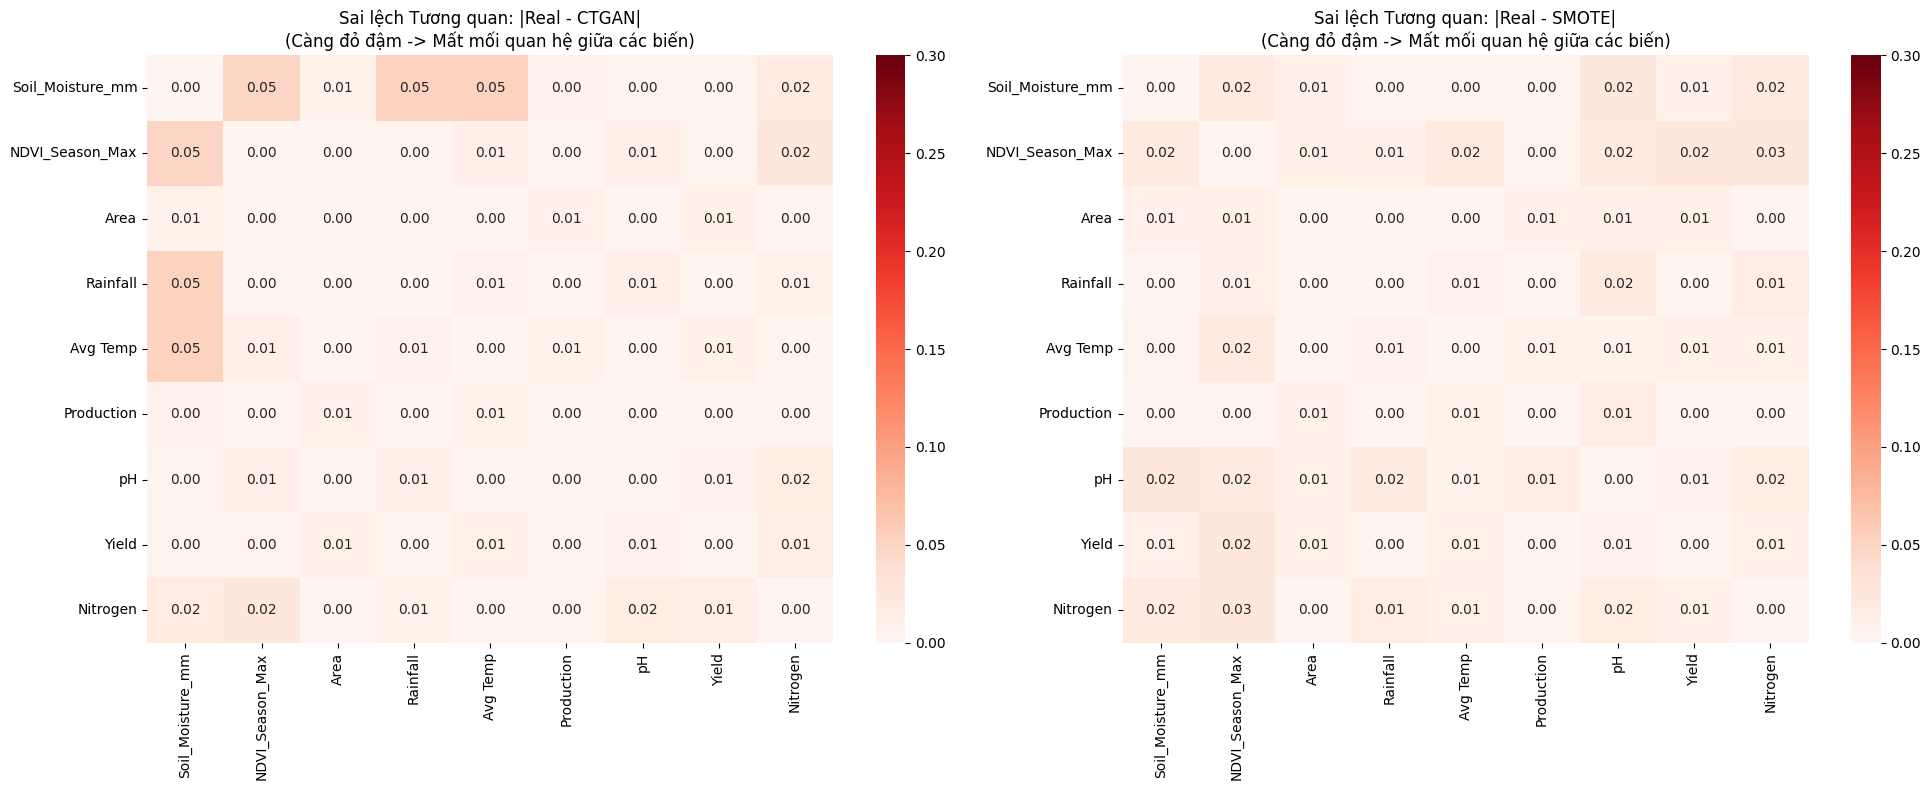

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp

# ---------------------------------------------------------
# 1. TẢI DỮ LIỆU
# ---------------------------------------------------------
print("Đang tải dữ liệu...")
real_data = pd.read_csv('Agri_Data_Cleaned.csv')
ctgan_data = pd.read_csv('Agri_Data_SMOTE_Noise_v3.csv')
smote_data = pd.read_csv('Agri_Data_SMOTE_Noise_v4.csv')

# Chọn các cột số quan trọng để đánh giá
# (Loại bỏ các cột ID hoặc quá ít giá trị để tránh nhiễu)
numeric_cols = ['Yield', 'Rainfall', 'Avg Temp', 'pH', 'Nitrogen', 
                'Soil_Moisture_mm', 'NDVI_Season_Max', 'Area', 'Production']

# Lọc chỉ lấy các cột thực sự tồn tại trong cả 3 file
common_cols = list(set(numeric_cols) & set(real_data.columns) & set(ctgan_data.columns))

# ---------------------------------------------------------
# 2. HÀM TÍNH TOÁN CHỈ SỐ (METRICS)
# ---------------------------------------------------------
def evaluate_synthetic_data(real, synthetic, columns, name):
    results = []
    
    # A. So sánh Tương quan (Correlation Matrix Difference)
    corr_real = real[columns].corr().fillna(0)
    corr_syn = synthetic[columns].corr().fillna(0)
    # Frobenius Norm: Tổng bình phương sai lệch giữa các ô trong ma trận
    corr_diff_matrix = abs(corr_real - corr_syn)
    avg_corr_diff = corr_diff_matrix.mean().mean()
    
    # B. So sánh từng biến đơn lẻ (Univariate)
    print(f"\n--- Đánh giá chi tiết: {name} ---")
    print(f"{'Column':<20} | {'KS Stat (Low=Good)':<20} | {'Mean Diff %':<15} | {'Std Diff %':<15}")
    print("-" * 80)
    
    for col in columns:
        r_col = real[col].dropna()
        s_col = synthetic[col].dropna()
        
        # 1. KS Test (Kiểm định phân phối)
        ks_stat, _ = ks_2samp(r_col, s_col)
        
        # 2. Sai số Trung bình (Mean Error)
        mean_err = abs(r_col.mean() - s_col.mean()) / (abs(r_col.mean()) + 1e-6) * 100
        
        # 3. Sai số Độ lệch chuẩn (Std Error)
        std_err = abs(r_col.std() - s_col.std()) / (r_col.std() + 1e-6) * 100
        
        results.append({
            'Method': name,
            'Column': col,
            'KS_Stat': ks_stat,
            'Mean_Diff_%': mean_err,
            'Std_Diff_%': std_err
        })
        
        print(f"{col:<20} | {ks_stat:.4f}               | {mean_err:.2f}%          | {std_err:.2f}%")
        
    print(f"\n>> Sai lệch Tương quan trung bình ({name}): {avg_corr_diff:.4f}")
    return pd.DataFrame(results), corr_real, corr_syn

# ---------------------------------------------------------
# 3. THỰC HIỆN ĐÁNH GIÁ
# ---------------------------------------------------------
df_res_ctgan, corr_real, corr_ctgan = evaluate_synthetic_data(real_data, ctgan_data, common_cols, "CTGAN")
df_res_smote, _, corr_smote = evaluate_synthetic_data(real_data, smote_data, common_cols, "SMOTE")

# Tổng hợp so sánh
summary = pd.concat([df_res_ctgan, df_res_smote])
avg_scores = summary.groupby('Method')[['KS_Stat', 'Mean_Diff_%', 'Std_Diff_%']].mean()
print("\n========================================================")
print("BẢNG ĐIỂM TỔNG KẾT (TRUNG BÌNH CÁC CỘT)")
print("========================================================")
print(avg_scores)
print("\nNhận xét:")
print("- KS_Stat càng thấp: Phân phối dữ liệu càng giống thật.")
print("- Mean/Std Diff càng thấp: Giá trị trung bình/độ lệch càng chuẩn.")

# ---------------------------------------------------------
# 4. VẼ BIỂU ĐỒ (VISUALIZATION)
# ---------------------------------------------------------

# A. Biểu đồ Phân phối (Density Plot)
# Vẽ 6 biến quan trọng nhất
plot_cols = common_cols[:6] 
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(plot_cols):
    sns.kdeplot(real_data[col], ax=axes[i], label='Real', color='blue', fill=True, alpha=0.1, linewidth=2)
    sns.kdeplot(ctgan_data[col], ax=axes[i], label='CTGAN', color='orange', linestyle='--')
    sns.kdeplot(smote_data[col], ax=axes[i], label='SMOTE', color='green', linestyle=':')
    axes[i].set_title(f'Distribution: {col}')
    axes[i].legend()

plt.tight_layout()
plt.savefig('comparison_distributions.png')
print("\nĐã lưu biểu đồ phân phối: comparison_distributions.png")

# B. Biểu đồ Sai lệch Tương quan (Correlation Difference Heatmap)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Tính sai lệch tuyệt đối: |Real - Synthetic|
diff_ctgan = abs(corr_real - corr_ctgan)
diff_smote = abs(corr_real - corr_smote)

sns.heatmap(diff_ctgan, ax=ax1, cmap='Reds', annot=True, fmt=".2f", vmin=0, vmax=0.3)
ax1.set_title('Sai lệch Tương quan: |Real - CTGAN|\n(Càng đỏ đậm -> Mất mối quan hệ giữa các biến)')

sns.heatmap(diff_smote, ax=ax2, cmap='Reds', annot=True, fmt=".2f", vmin=0, vmax=0.3)
ax2.set_title('Sai lệch Tương quan: |Real - SMOTE|\n(Càng đỏ đậm -> Mất mối quan hệ giữa các biến)')

plt.tight_layout()
plt.savefig('comparison_correlations.png')
print("Đã lưu biểu đồ tương quan: comparison_correlations.png")